In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_style("whitegrid")
# plt.rcParams['figure.figsize'] = (12, 6)
# plt.rcParams['font.size'] = 10

In [268]:
df = pd.read_csv('osu_plays.csv')
df.head(5)

,song_title,artist,genre,id,beatmap_id,date_started,date_ended,accuracy,max_combo_player,max_combo_beatmap,...,ar,cs,bpm,hit_length,count_circles,count_sliders,count_spinners,difficulty_rating,beatmap_type,played_before
0,Anoko Secret,Eve,Rock,6176870141,1788240,2026-02-07 00:10:01+08:00,2026-02-07 00:11:48+08:00,90.58,320,643,...,9.0,4.0,160.0,100,276,180,2,4.81082,Hybrid,True
1,Anoko Secret,Eve,Rock,6176913489,1788240,2026-02-07 00:18:35+08:00,2026-02-07 00:20:21+08:00,88.97,185,643,...,9.0,4.0,160.0,100,276,180,2,4.81082,Hybrid,True
2,Rubik's Cube,Hatsune Miku,Rock,6176949608,114635,2026-02-07 00:24:38+08:00,2026-02-07 00:27:31+08:00,88.20,93,1027,...,9.0,4.0,174.0,151,470,246,1,5.53040,Hybrid,True
3,Playing With Fire,kors k,Video Game,6177128241,2015158,2026-02-07 01:00:34+08:00,2026-02-07 01:02:20+08:00,89.57,316,617,...,9.0,4.0,160.0,93,262,136,4,4.55318,Tech,False
4,Koi no Hime Hime Pettanko,*namirin,Anime,6177375094,1053519,2026-02-07 01:48:38+08:00,2026-02-07 01:50:15+08:00,95.68,461,502,...,9.0,4.0,178.0,92,213,143,0,4.62552,Jump,True


In [269]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   song_title         300 non-null    str    
 1   artist             300 non-null    str    
 2   genre              300 non-null    str    
 3   id                 300 non-null    int64  
 4   beatmap_id         300 non-null    int64  
 5   date_started       300 non-null    str    
 6   date_ended         300 non-null    str    
 7   accuracy           300 non-null    float64
 8   max_combo_player   300 non-null    int64  
 9   max_combo_beatmap  300 non-null    int64  
 10  is_perfect_combo   300 non-null    bool   
 11  passed             300 non-null    bool   
 12  max_great          300 non-null    int64  
 13  great              300 non-null    int64  
 14  ok                 300 non-null    int64  
 15  meh                243 non-null    float64
 16  miss               297 non-null    fl

In [270]:
display(df.describe())

,id,beatmap_id,accuracy,max_combo_player,max_combo_beatmap,max_great,great,ok,meh,miss,ar,cs,bpm,hit_length,count_circles,count_sliders,count_spinners,difficulty_rating
count,3.000000e+02,3.000000e+02,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,243.000000,297.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,6.198407e+09,1.336571e+06,91.737533,352.176667,1192.573333,780.700000,653.476667,74.616667,8.987654,17.417508,9.125333,3.990000,179.190567,176.343333,459.883333,319.163333,1.653333,5.468128
std,1.428741e+07,1.084394e+06,5.472786,226.359347,569.267867,348.584798,304.808393,66.001898,9.844444,13.341693,0.191696,0.233556,22.769728,73.431096,233.659980,164.936605,1.606786,0.400477
min,6.176870e+09,1.114390e+05,70.230000,68.000000,402.000000,282.000000,86.000000,2.000000,1.000000,1.000000,8.000000,3.000000,87.000000,73.000000,149.000000,74.000000,0.000000,4.447440
25%,6.186518e+09,4.847290e+05,88.712500,188.500000,745.000000,503.000000,410.500000,22.750000,2.000000,7.000000,9.000000,4.000000,170.000000,113.000000,294.000000,175.000000,1.000000,5.192410
50%,6.193125e+09,1.050174e+06,92.855000,292.500000,1093.000000,732.000000,596.000000,54.000000,6.000000,15.000000,9.000000,4.000000,175.000000,164.000000,422.000000,286.500000,1.000000,5.446115
75%,6.213202e+09,1.741822e+06,95.825000,450.500000,1508.750000,961.500000,820.250000,110.500000,12.000000,24.000000,9.200000,4.000000,190.000000,216.000000,542.750000,416.000000,2.000000,5.796730
max,6.224199e+09,5.194045e+06,99.230000,1301.000000,3273.000000,1880.000000,1747.000000,427.000000,65.000000,68.000000,10.000000,5.700000,320.000000,441.000000,1338.000000,870.000000,8.000000,6.305370


# Data Pre-processing

In [271]:
df.isnull().sum()

song_title            0
artist                0
genre                 0
id                    0
beatmap_id            0
date_started          0
date_ended            0
accuracy              0
max_combo_player      0
max_combo_beatmap     0
is_perfect_combo      0
passed                0
max_great             0
great                 0
ok                    0
meh                  57
miss                  3
ar                    0
cs                    0
bpm                   0
hit_length            0
count_circles         0
count_sliders         0
count_spinners        0
difficulty_rating     0
beatmap_type          0
played_before         0
dtype: int64

In [272]:
df['meh'] = df['meh'].fillna(0)
df['miss'] = df['miss'].fillna(0)

print(df.isnull().sum())

song_title           0
artist               0
genre                0
id                   0
beatmap_id           0
date_started         0
date_ended           0
accuracy             0
max_combo_player     0
max_combo_beatmap    0
is_perfect_combo     0
passed               0
max_great            0
great                0
ok                   0
meh                  0
miss                 0
ar                   0
cs                   0
bpm                  0
hit_length           0
count_circles        0
count_sliders        0
count_spinners       0
difficulty_rating    0
beatmap_type         0
played_before        0
dtype: int64


In [273]:
df.duplicated().sum()

np.int64(0)

In [274]:
df['combo_ratio'] = (df['max_combo_player'] / df['max_combo_beatmap'])
print("Combo Completion:")
print(f"  Range: {df['combo_ratio'].min():.2f}% to {df['combo_ratio'].max():.2f}%")
print(f"  Mean: {df['combo_ratio'].mean():.2f}%, SD: {df['combo_ratio'].std():.2f}%")
print()

df['total_objects'] = df['count_circles'] + df['count_sliders'] + df['count_spinners']
df['object_density'] = df['total_objects'] / df['hit_length']
print("Object Density:")
print(f"  Range: {df['object_density'].min():.2f} to {df['object_density'].max():.2f} objects/sec")
print(f"  Mean: {df['object_density'].mean():.2f} objects/sec")
print()

df['miss_rate'] = (df['miss'] / df['total_objects'])
print("Miss Rate:")
print(f"  Range: {df['miss_rate'].min():.2f}% to {df['miss_rate'].max():.2f}%")
print(f"  Mean: {df['miss_rate'].mean():.2f}%")
print()

df['date_started'] = pd.to_datetime(df['date_started'])
df = df.sort_values('date_started').reset_index(drop=True)

df['day'] = (df['date_started'] - df['date_started'].min()).dt.days
print("Days since start:")
print(f"  Range: 0 to {df['day'].max()} days")
print()

df['hour'] = df['date_started'].dt.hour
print("Hour of day:")
print(f"  Range: {df['hour'].min()} to {df['hour'].max()}")
print()

Combo Completion:
  Range: 0.04% to 1.00%
  Mean: 0.33%, SD: 0.21%

Object Density:
  Range: 2.95 to 7.67 objects/sec
  Mean: 4.44 objects/sec

Miss Rate:
  Range: 0.00% to 0.10%
  Mean: 0.02%

Days since start:
  Range: 0 to 8 days

Hour of day:
  Range: 0 to 23



# EDA

In [275]:
df = df.drop(['song_title','artist','id','beatmap_id','date_started', 'date_ended'], axis=1)
df.head(5)

,genre,accuracy,max_combo_player,max_combo_beatmap,is_perfect_combo,passed,max_great,great,ok,meh,...,count_spinners,difficulty_rating,beatmap_type,played_before,combo_ratio,total_objects,object_density,miss_rate,day,hour
0,Rock,90.58,320,643,False,True,458,386,63,2.0,...,2,4.81082,Hybrid,True,0.497667,458,4.580000,0.015284,0,0
1,Rock,88.97,185,643,False,True,458,377,59,8.0,...,2,4.81082,Hybrid,True,0.287714,458,4.580000,0.030568,0,0
2,Rock,88.20,93,1027,False,True,717,592,90,3.0,...,1,5.53040,Hybrid,True,0.090555,717,4.748344,0.044630,0,0
3,Video Game,89.57,316,617,False,True,402,337,47,9.0,...,4,4.55318,Tech,False,0.512156,402,4.322581,0.022388,0,1
4,Anime,95.68,461,502,False,True,356,330,21,3.0,...,0,4.62552,Jump,True,0.918327,356,3.869565,0.005618,0,1


In [276]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genre              300 non-null    str    
 1   accuracy           300 non-null    float64
 2   max_combo_player   300 non-null    int64  
 3   max_combo_beatmap  300 non-null    int64  
 4   is_perfect_combo   300 non-null    bool   
 5   passed             300 non-null    bool   
 6   max_great          300 non-null    int64  
 7   great              300 non-null    int64  
 8   ok                 300 non-null    int64  
 9   meh                300 non-null    float64
 10  miss               300 non-null    float64
 11  ar                 300 non-null    float64
 12  cs                 300 non-null    float64
 13  bpm                300 non-null    float64
 14  hit_length         300 non-null    int64  
 15  count_circles      300 non-null    int64  
 16  count_sliders      300 non-null    in

## Univariate Analysis

Numeric

In [277]:
numeric_columns = [
    'accuracy', 'max_combo_player', 'max_combo_beatmap', 'max_great', 
    'great', 'ok', 'meh', 'miss', 'ar', 'cs', 'bpm', 'hit_length', 
    'count_circles', 'count_sliders', 'count_spinners', 'difficulty_rating', 
    'combo_ratio', 'miss_rate', 'total_objects', 'object_density', 'hour', 'day'
]

summary_stats = df[numeric_columns].describe().T
print("Numeric Feature Summary")
print(summary_stats)

Numeric Feature Summary
                   count         mean         std         min         25%  \
accuracy           300.0    91.737533    5.472786   70.230000   88.712500   
max_combo_player   300.0   352.176667  226.359347   68.000000  188.500000   
max_combo_beatmap  300.0  1192.573333  569.267867  402.000000  745.000000   
max_great          300.0   780.700000  348.584798  282.000000  503.000000   
great              300.0   653.476667  304.808393   86.000000  410.500000   
ok                 300.0    74.616667   66.001898    2.000000   22.750000   
meh                300.0     7.280000    9.534742    0.000000    1.000000   
miss               300.0    17.243333   13.387614    0.000000    7.000000   
ar                 300.0     9.125333    0.191696    8.000000    9.000000   
cs                 300.0     3.990000    0.233556    3.000000    4.000000   
bpm                300.0   179.190567   22.769728   87.000000  170.000000   
hit_length         300.0   176.343333   73.431096   

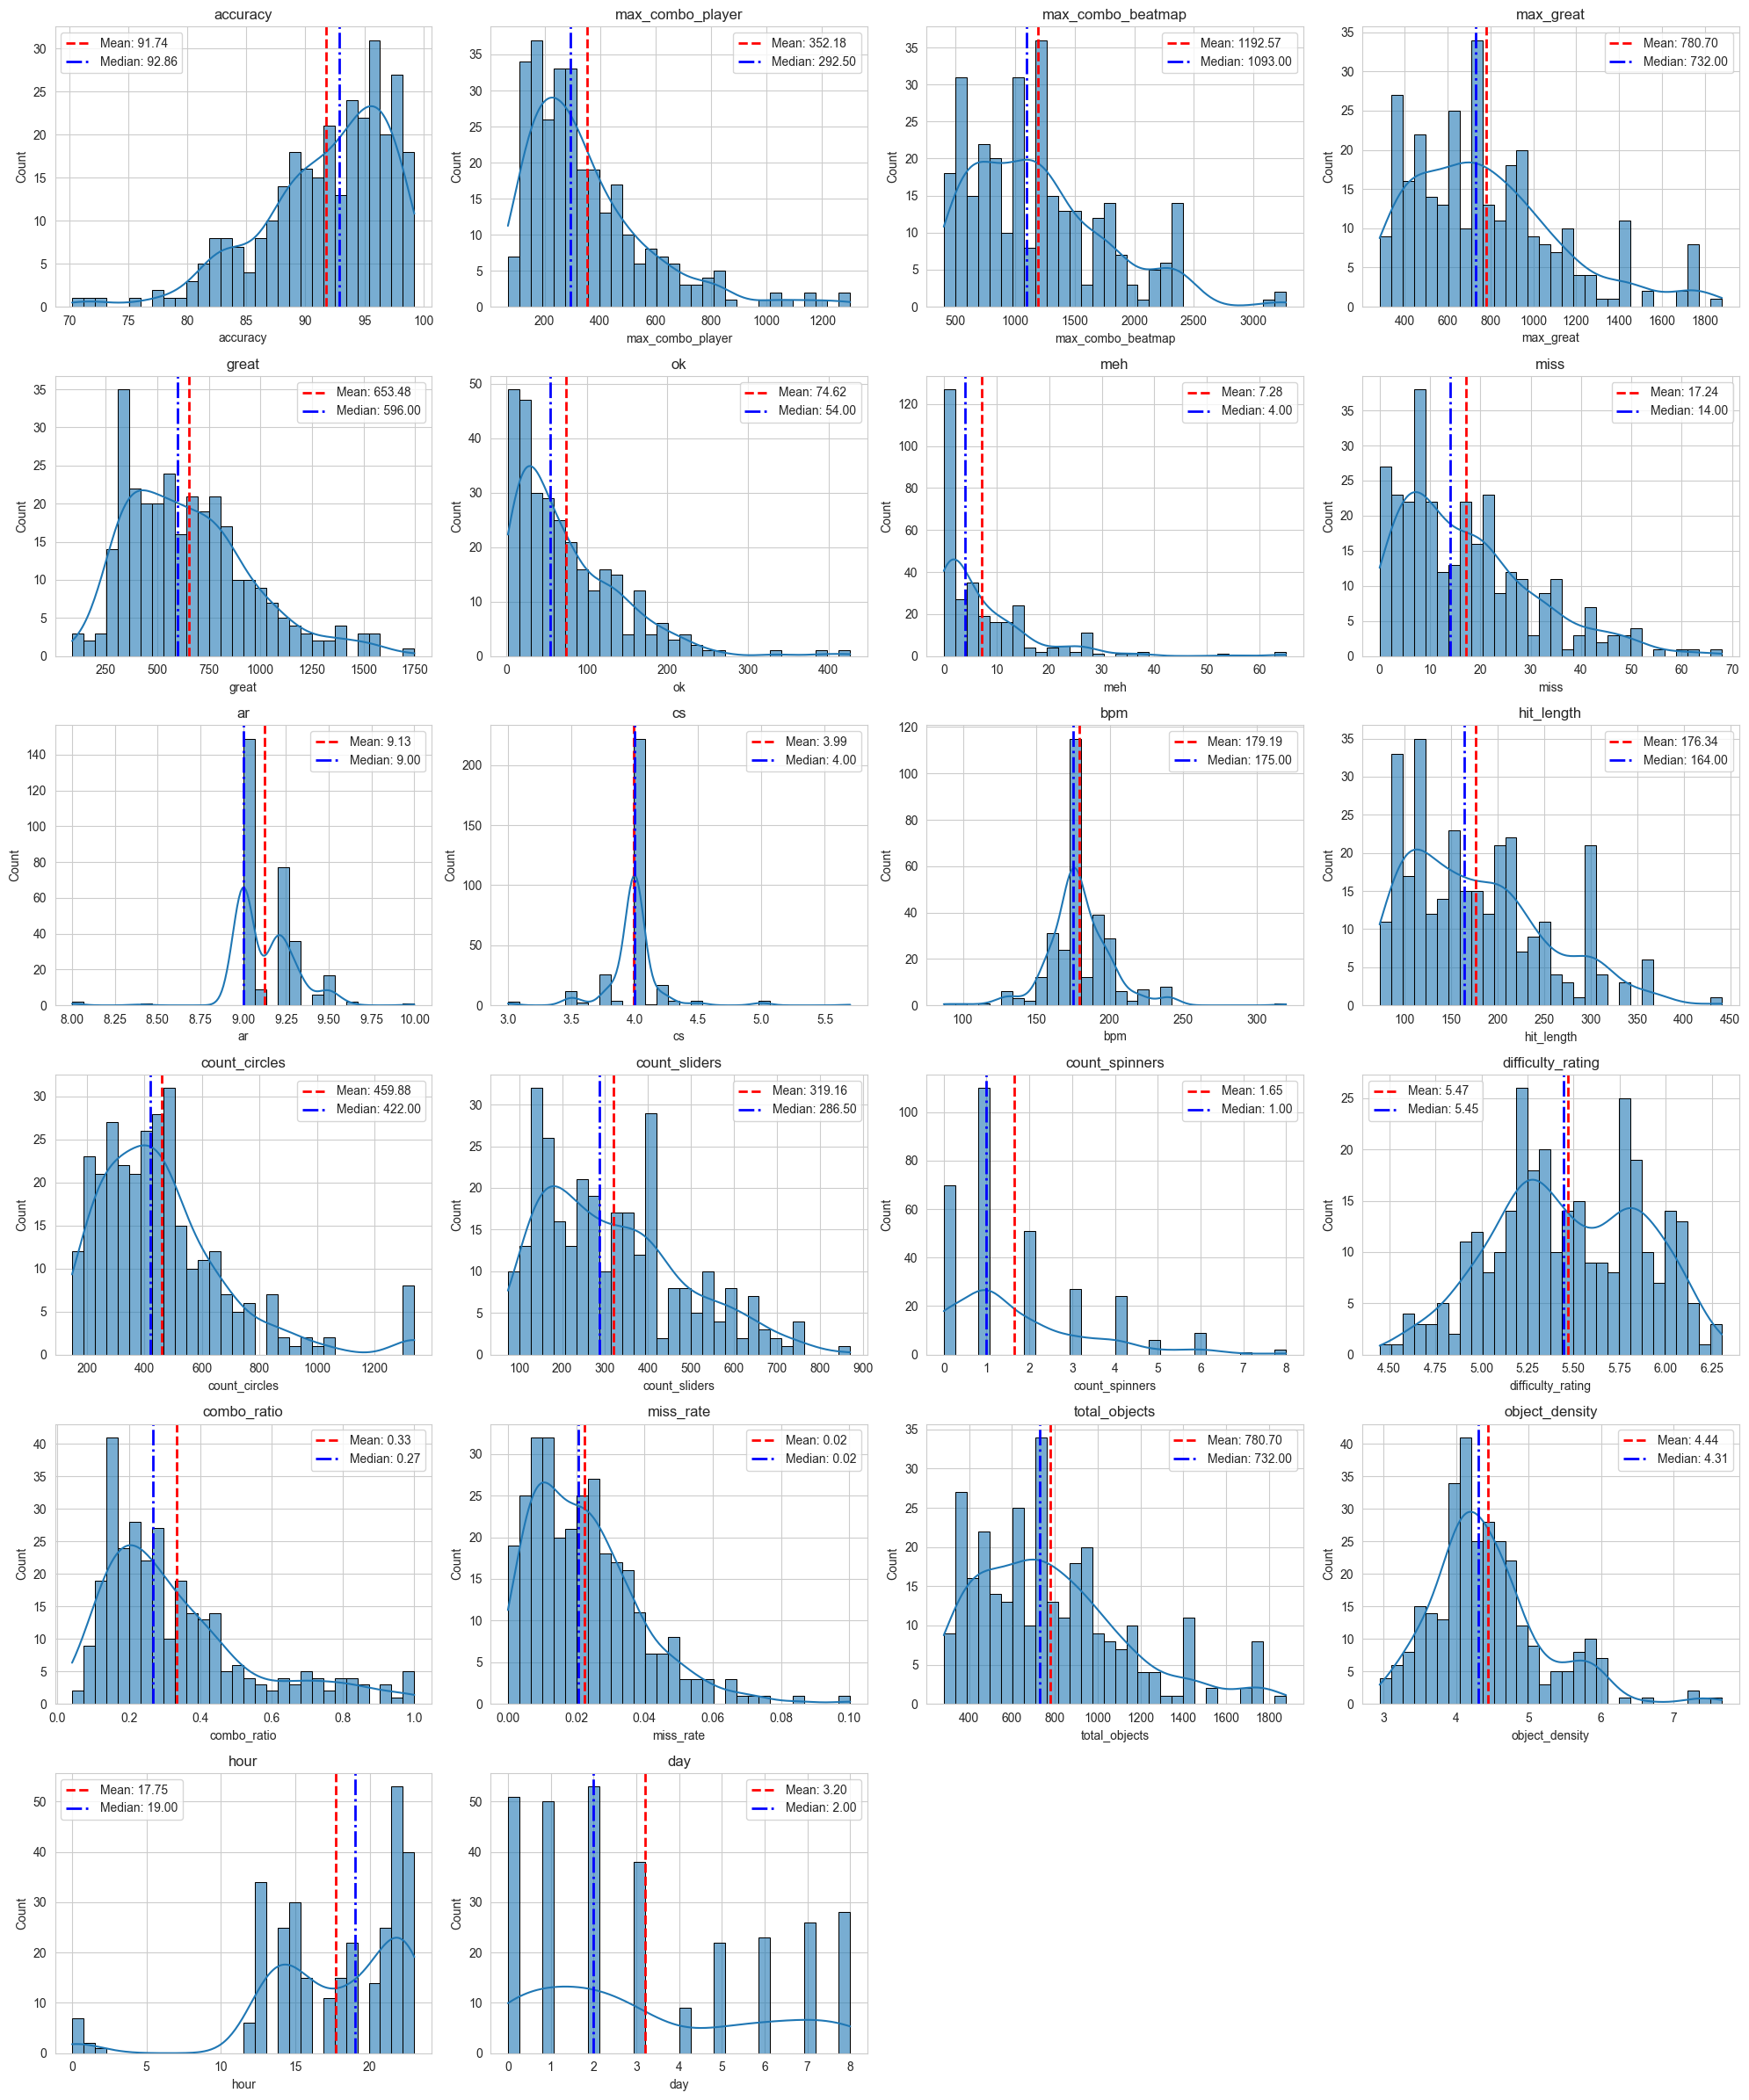

In [278]:
cols_per_row = 4
rows = (len(numeric_columns) + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_columns):
    column_data = df[col].dropna()
    
    sns.histplot(column_data, bins=30, kde=True, ax=axes[idx], edgecolor='black', alpha=0.6)
    
    mean_val = column_data.mean()
    median_val = column_data.median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='blue', linestyle='-.', linewidth=2, label=f'Median: {median_val:.2f}')

    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("performance_metrics_hist.png", dpi=300)

Categorical and Boolean

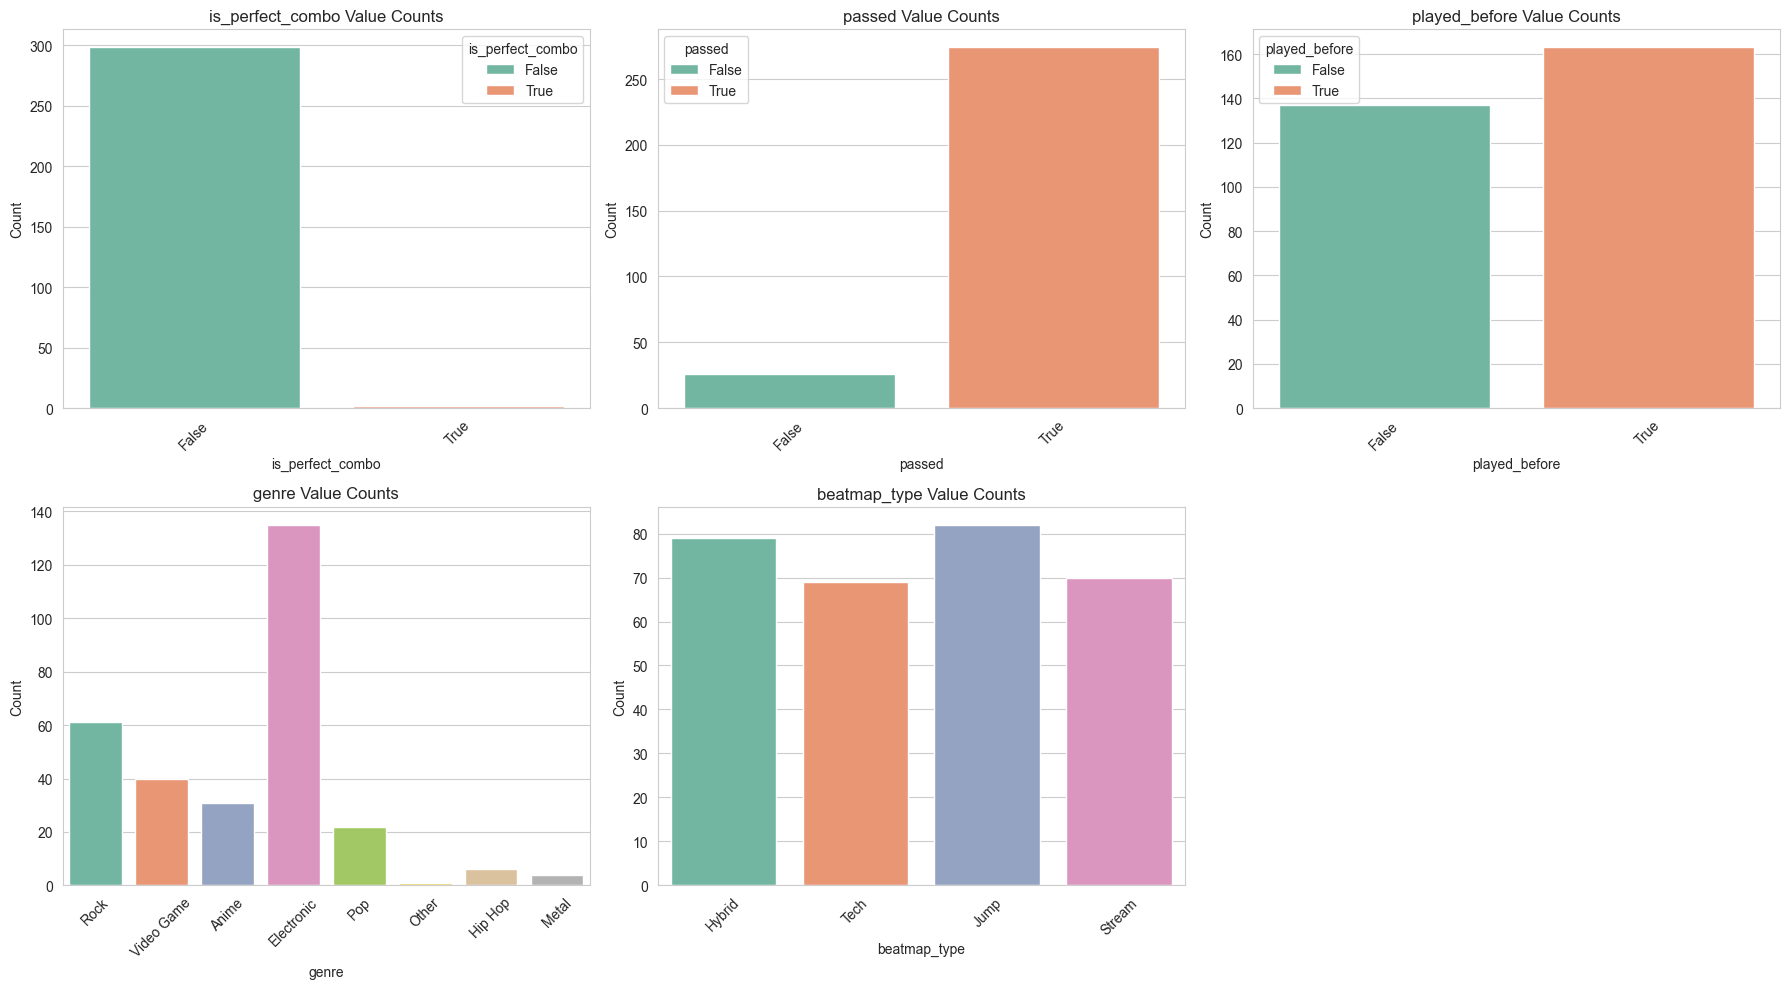

is_perfect_combo
False    298
True       2
Name: count, dtype: int64


passed
True     274
False     26
Name: count, dtype: int64


played_before
True     163
False    137
Name: count, dtype: int64


genre
Electronic    135
Rock           61
Video Game     40
Anime          31
Pop            22
Hip Hop         6
Metal           4
Other           1
Name: count, dtype: int64


beatmap_type
Jump      82
Hybrid    79
Stream    70
Tech      69
Name: count, dtype: int64




In [279]:
cat_bool_cols = ['is_perfect_combo', 'passed', 'played_before', 'genre', 'beatmap_type']

n_cols = 3
n_rows = (len(cat_bool_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*5))
axes = axes.flatten()

for i, col in enumerate(cat_bool_cols):
    sns.countplot(x=col, data=df, hue=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} Value Counts')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

for col in cat_bool_cols:
    print(df[col].value_counts())
    print("\n")

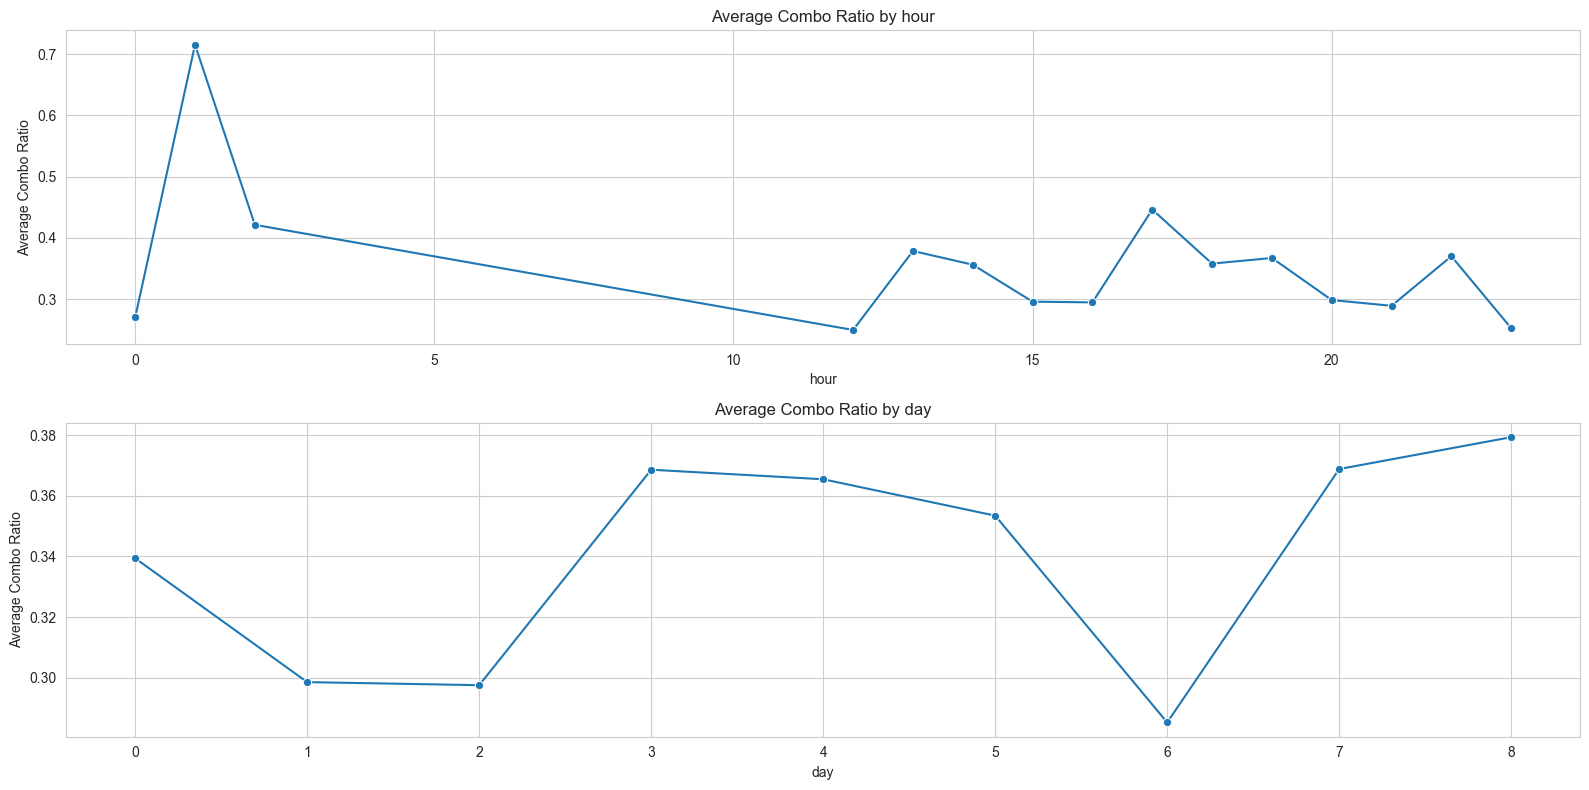

In [280]:
time_columns = ['hour', 'day']

cols_per_row = 1
rows = (len(time_columns) + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(time_columns):
    grouped = df.groupby(col)['combo_ratio'].mean().reset_index()
    
    sns.lineplot(x=col, y='combo_ratio', data=grouped, ax=axes[idx], marker='o')
    
    axes[idx].set_title(f'Average Combo Ratio by {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Average Combo Ratio')

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Bivariate Analysis

Numeric and Numeric (Based on Combo Ratio)

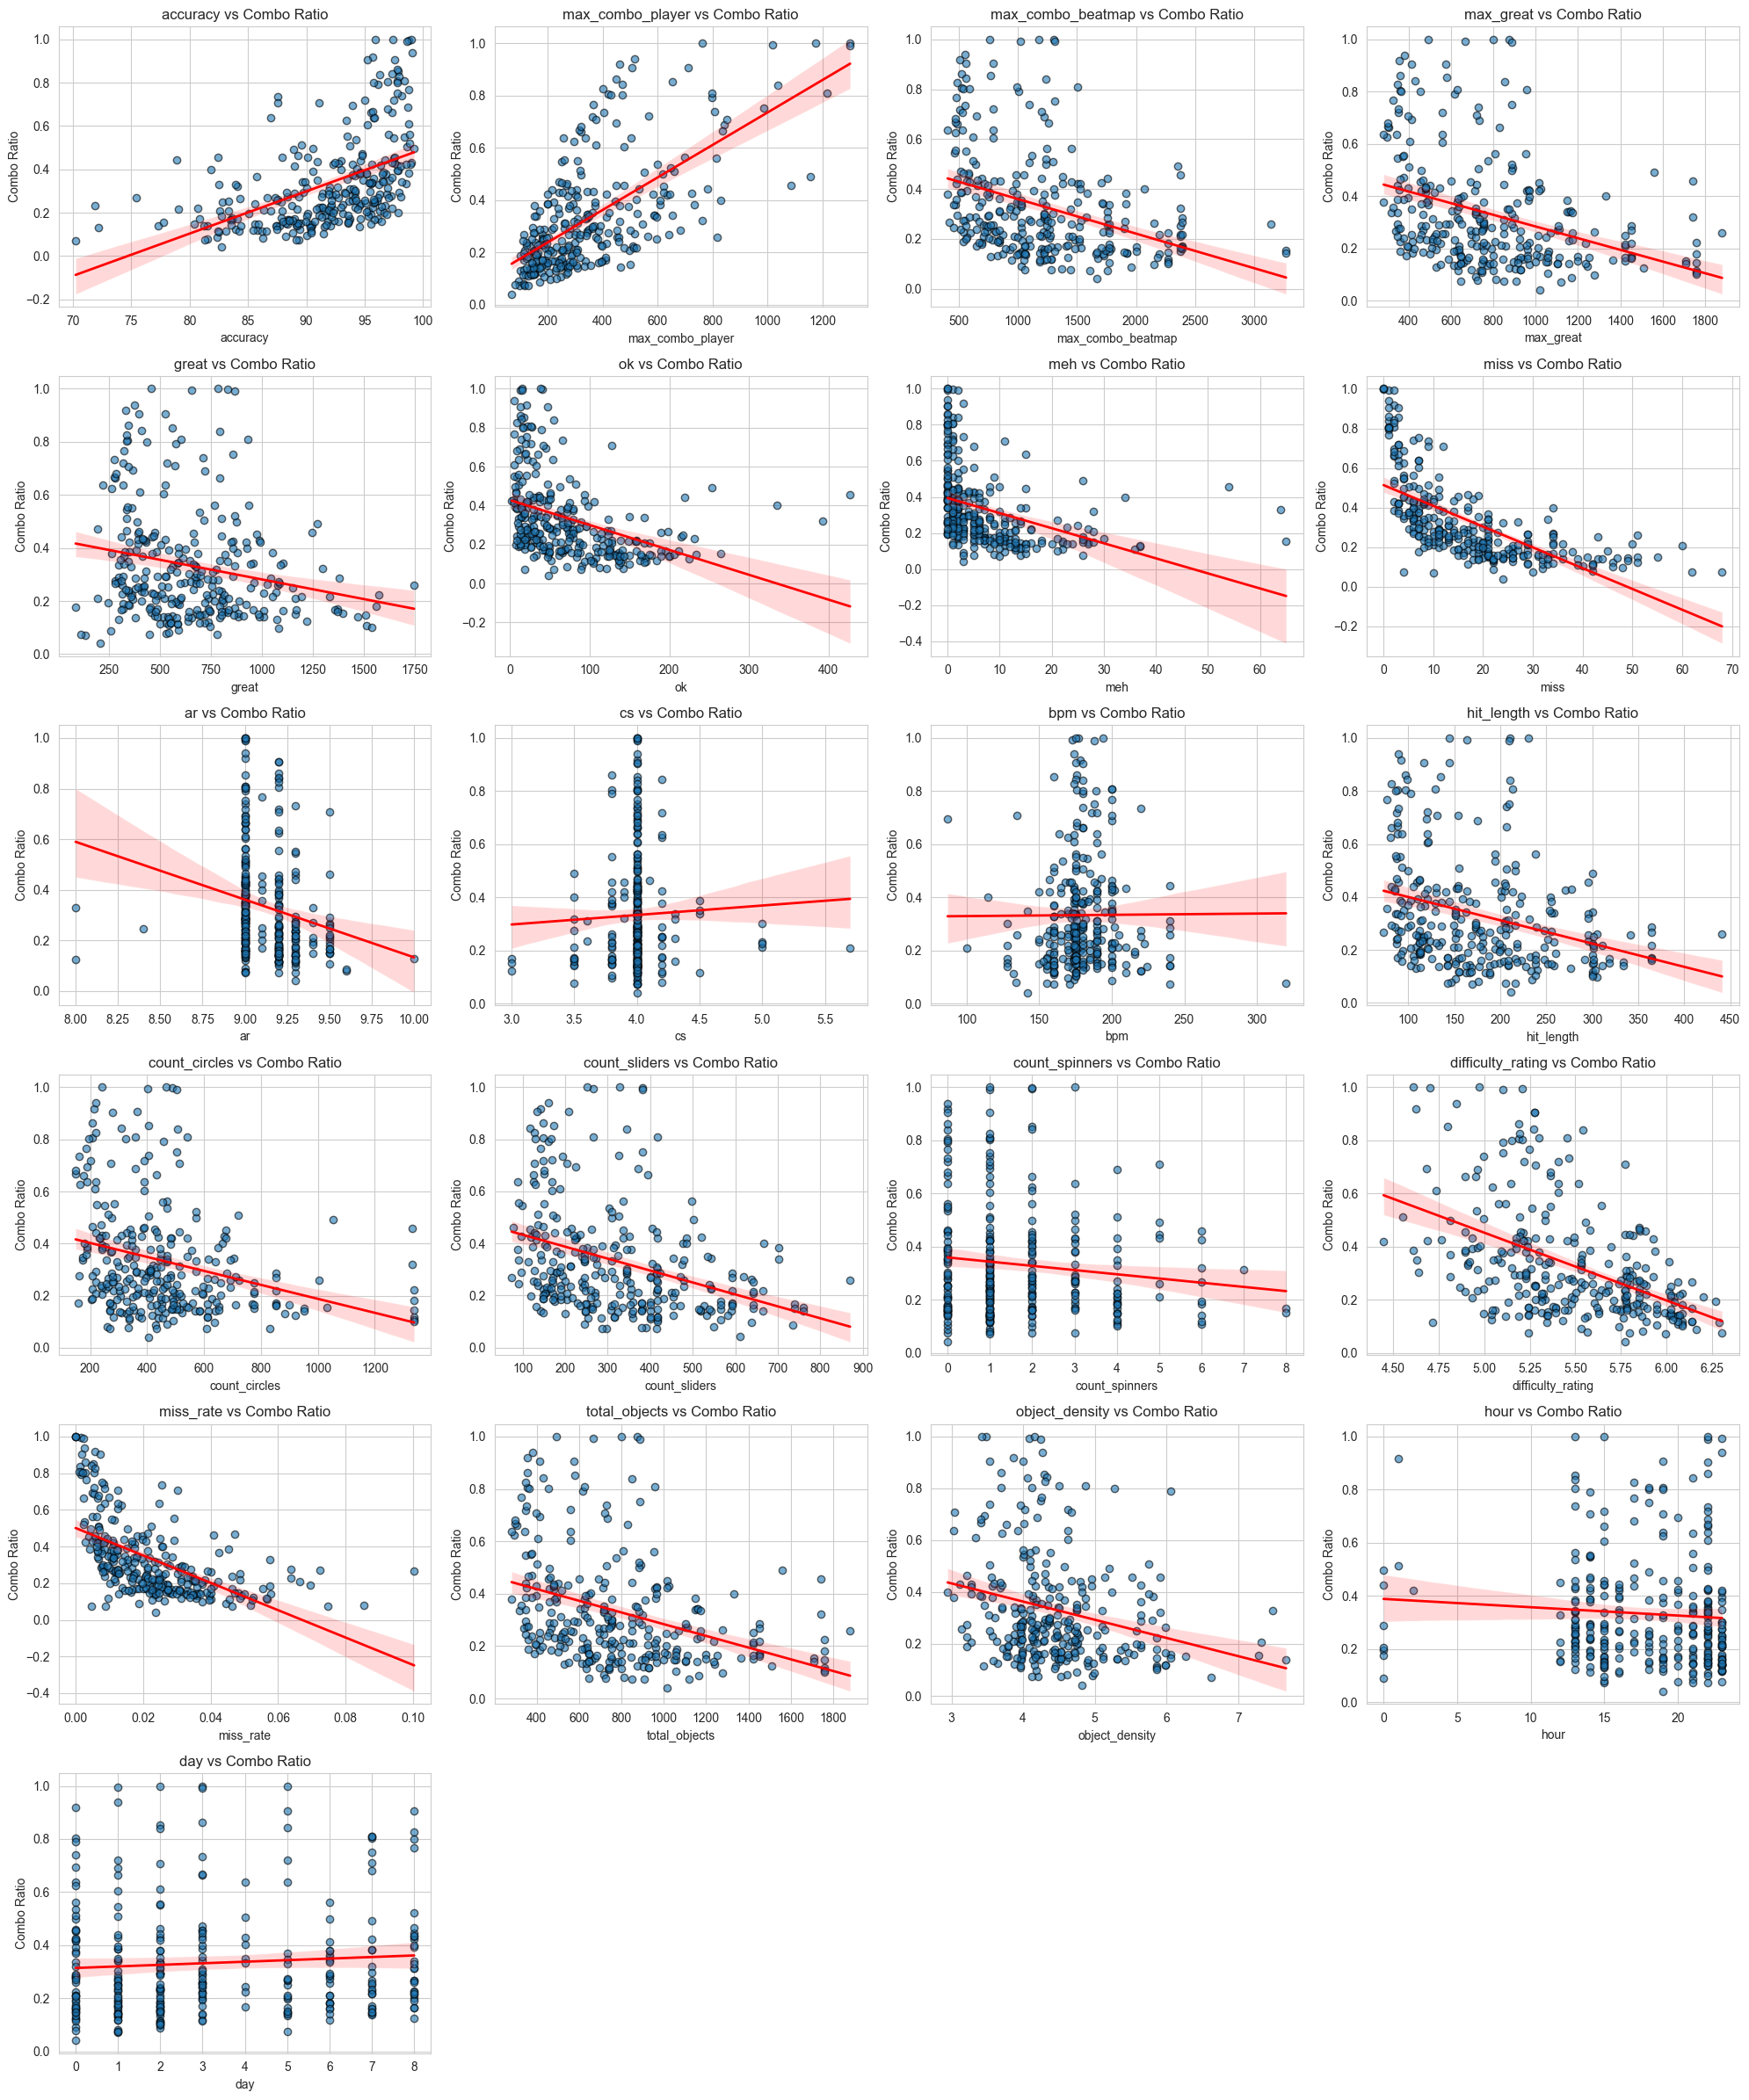

In [281]:
numeric_columns = [
    'accuracy', 'max_combo_player', 'max_combo_beatmap', 'max_great', 
    'great', 'ok', 'meh', 'miss', 'ar', 'cs', 'bpm', 'hit_length', 
    'count_circles', 'count_sliders', 'count_spinners', 'difficulty_rating', 
    'miss_rate', 'total_objects', 'object_density', 'hour', 'day'
]

cols_per_row = 4
rows = (len(numeric_columns) + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_columns):
    sns.regplot(x=col, y='combo_ratio', data=df, ax=axes[idx],
                scatter_kws={'alpha':0.6, 'edgecolor':'black'},
                line_kws={'color':'red', 'linewidth':2})
    
    axes[idx].set_title(f'{col} vs Combo Ratio')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Combo Ratio')

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Numeric and Categorical/Boolean

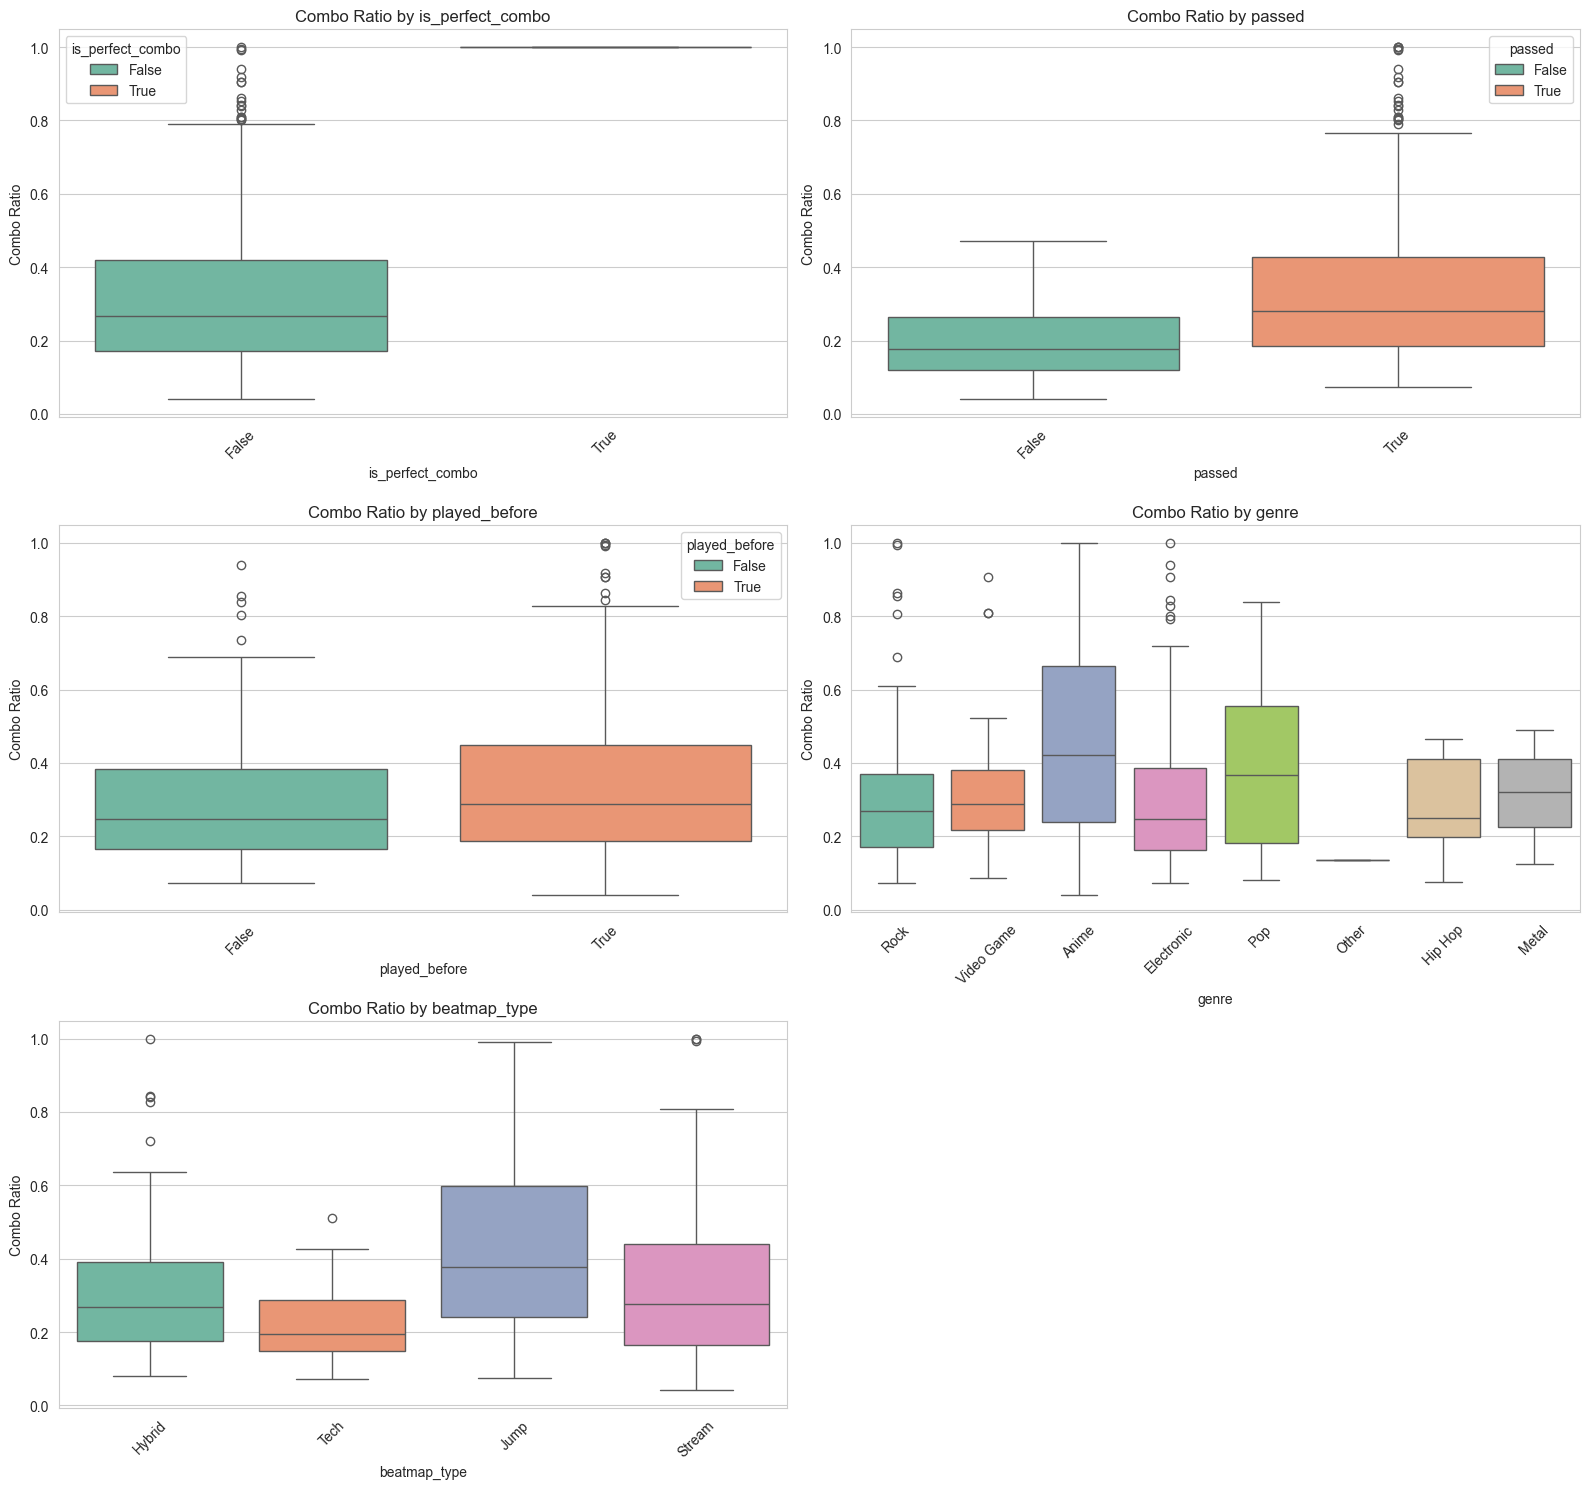

In [282]:
n_cols = 2
n_rows = (len(cat_bool_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*8, n_rows*5))
axes = axes.flatten()

for idx, col in enumerate(cat_bool_cols):
    sns.boxplot(x=col, y='combo_ratio', data=df, hue=col, palette='Set2', ax=axes[idx])
    axes[idx].set_title(f'Combo Ratio by {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Combo Ratio')
    axes[idx].tick_params(axis='x', rotation=45)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [283]:
df.groupby('is_perfect_combo')['combo_ratio'].agg(['mean', 'std'])

,mean,std
is_perfect_combo,,
False,0.328351,0.206914
True,1.000000,0.000000


In [284]:
df.groupby('passed')['combo_ratio'].agg(['mean', 'std'])

,mean,std
passed,,
False,0.199152,0.111672
True,0.345513,0.216459


In [285]:
df.groupby('played_before')['combo_ratio'].agg(['mean', 'std'])

,mean,std
played_before,,
False,0.294116,0.172169
True,0.365366,0.238339


In [286]:
df.groupby('genre')['combo_ratio'].agg(['mean', 'std'])

,mean,std
genre,,
Anime,0.463050,0.264858
Electronic,0.301391,0.196351
Hip Hop,0.280921,0.154244
Metal,0.314309,0.157861
Other,0.135895,NaN
Pop,0.400965,0.238699
Rock,0.324665,0.217327
Video Game,0.327547,0.182166


In [287]:
df.groupby('beatmap_type')['combo_ratio'].agg(['mean', 'std'])

,mean,std
beatmap_type,,
Hybrid,0.313975,0.192519
Jump,0.431887,0.232722
Stream,0.349399,0.239146
Tech,0.219883,0.098185


# Statistical Test

In [288]:
numeric_columns = [
    'accuracy', 'max_combo_player', 'max_combo_beatmap', 'max_great', 
    'great', 'ok', 'meh', 'miss', 'ar', 'cs', 'bpm', 'hit_length', 
    'count_circles', 'count_sliders', 'count_spinners', 'difficulty_rating', 
    'miss_rate', 'total_objects', 'object_density', 'day', 'hour'
]

correlations = df[numeric_columns + ['combo_ratio']].corr()['combo_ratio'].sort_values(key=abs, ascending=False)
print(correlations)

combo_ratio          1.000000
max_combo_player     0.658239
miss                -0.657986
miss_rate           -0.565569
accuracy             0.500939
difficulty_rating   -0.479208
ok                  -0.395319
meh                 -0.373453
max_combo_beatmap   -0.369630
max_great           -0.365285
total_objects       -0.365285
count_sliders       -0.354625
hit_length          -0.302449
count_circles       -0.293804
object_density      -0.256145
great               -0.211356
ar                  -0.205176
count_spinners      -0.119480
day                  0.073444
hour                -0.071328
cs                   0.039143
bpm                  0.005072
Name: combo_ratio, dtype: float64


In [289]:
target = 'combo_ratio'

numeric_features = ['miss','max_combo_player','miss_rate','accuracy','difficulty_rating',
                    'ok','meh','max_combo_beatmap','total_objects','max_great','count_sliders',
                    'hit_length', 'count_circles', 'object_density', 'great', 'ar']

categorical_features = ['beatmap_type','genre']
boolean_features = ['is_perfect_combo','played_before','passed']

In [290]:
print("=== Numeric Features ===")
print(f"{'Feature':<20} {'r':>7} {'p-value':>10}")
print("-" * 40)

for col in numeric_features:
    r, p = stats.pearsonr(df[col], df[target])

    if p < 0.001:
        p_display = "<0.0001"
    else:
        p_display = f"{p:.4f}"
    print(f"{col:<20} {r:>7.3f} {p_display:>10}")

=== Numeric Features ===
Feature                    r    p-value
----------------------------------------
miss                  -0.658    <0.0001
max_combo_player       0.658    <0.0001
miss_rate             -0.566    <0.0001
accuracy               0.501    <0.0001
difficulty_rating     -0.479    <0.0001
ok                    -0.395    <0.0001
meh                   -0.373    <0.0001
max_combo_beatmap     -0.370    <0.0001
total_objects         -0.365    <0.0001
max_great             -0.365    <0.0001
count_sliders         -0.355    <0.0001
hit_length            -0.302    <0.0001
count_circles         -0.294    <0.0001
object_density        -0.256    <0.0001
great                 -0.211    <0.0001
ar                    -0.205    <0.0001


In [291]:
print("\n=== Boolean Features ===")
print(f"{'Feature':<20} {'U-stat':>10} {'p-value':>10}")
print("-" * 45)

for col in boolean_features:
    group_true = df[df[col]==True][target]
    group_false = df[df[col]==False][target]

    u_stat, p_val = stats.mannwhitneyu(group_true, group_false, alternative='two-sided')

    if p_val < 0.001:
        p_display = "<0.0001"
    else:
        p_display = f"{p_val:.4f}"
    
    print(f"{col:<20} {u_stat:>10.3f} {p_display:>10}")



=== Boolean Features ===
Feature                  U-stat    p-value
---------------------------------------------
is_perfect_combo        596.000     0.0150
played_before         12840.500     0.0253
passed                 5142.000    <0.0001


In [292]:
print("\n=== Categorical Features ===")
print(f"{'Feature':<20} {'F-stat':>10} {'p-value':>10}")
print("-" * 45)

for col in categorical_features:
    groups = [df[df[col]==val][target] for val in df[col].unique()]
    f_stat, p_val = stats.f_oneway(*groups)

    if p_val < 0.001:
        p_display = "<0.0001"
    else:
        p_display = f"{p_val:.4f}"
    
    print(f"{col:<20} {f_stat:>10.3f} {p_display:>10}")


=== Categorical Features ===
Feature                  F-stat    p-value
---------------------------------------------
beatmap_type             14.386    <0.0001
genre                     2.684     0.0104


# Correlation Analysis

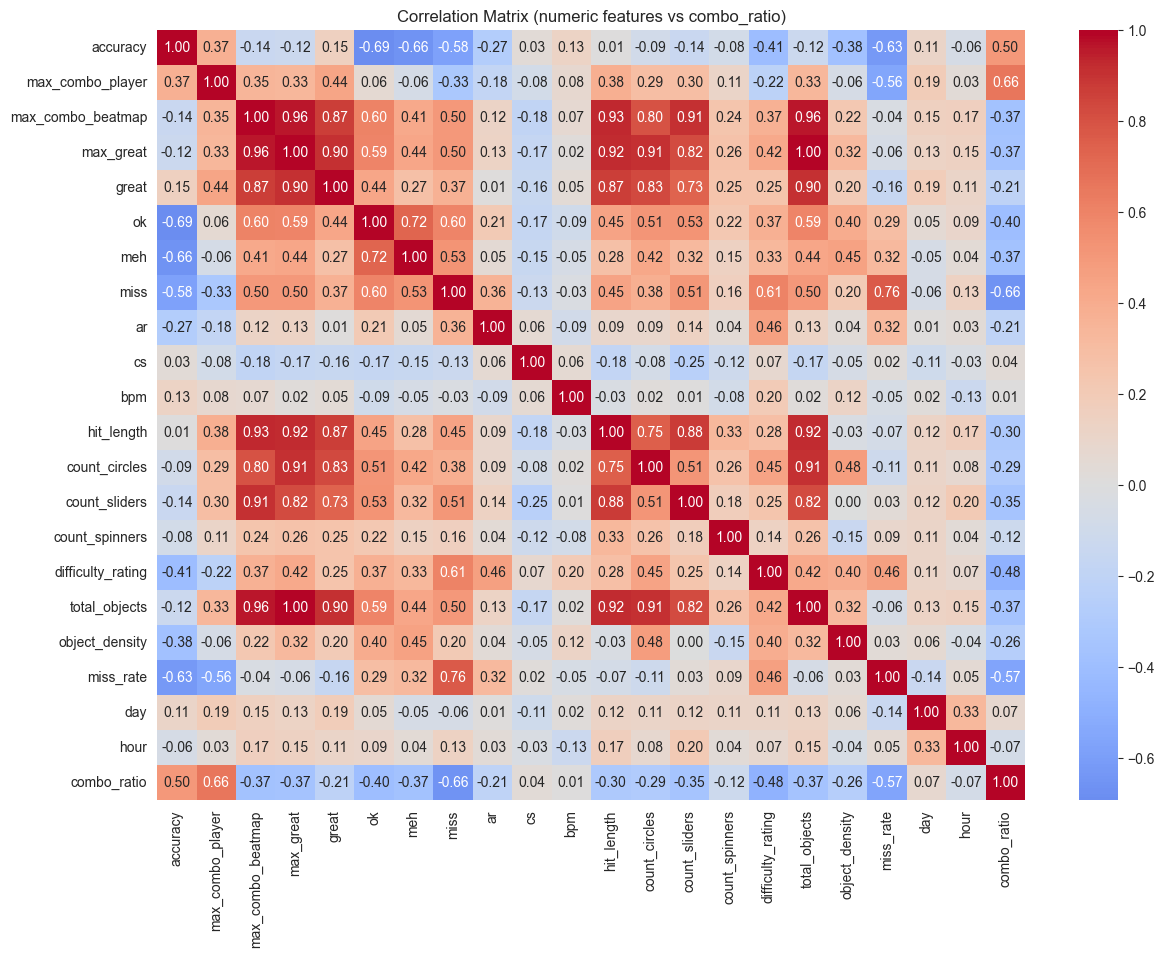

In [293]:
numeric_columns = [
    'accuracy', 'max_combo_player', 'max_combo_beatmap', 'max_great',
    'great', 'ok', 'meh', 'miss', 'ar', 'cs', 'bpm', 'hit_length',
    'count_circles', 'count_sliders', 'count_spinners', 'difficulty_rating',
    'total_objects', 'object_density', 'miss_rate', 'day', 'hour'
]

corr = df[numeric_columns + ['combo_ratio']].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (numeric features vs combo_ratio)")
plt.show()